# Blower door building air leakage test

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/cghiaus/dm4bem_book/HEAD?labpath=%2Ftutorials%2FA06Blow_door.ipynb)

[Building airtightness](https://en.wikipedia.org/wiki/Building_airtightness) is descibed by power law relation between pressure difference and air flow rate,

$$\dot{V} = K \cdot (\Delta p)^n$$

where:

- $\dot{V}$ is the volumetric leakage airflow rate, m³·h⁻¹;
- $\Delta p$ - induced pressure difference across the building envelope, Pa;
- $n$ - airflow exponent (0.5 ≤ $n$ ≤ 1);
- $K$ - air leakage coefficient, m³·h⁻¹·Pa⁻ⁿ.

The airflow exponent $n$ and the air leakage coefficient $K$ can be measured experimentally from data obtained in a [blower door test](https://en.m.wikipedia.org/wiki/Blower_door) for air leakage.

This notebook demonstrates how to determine the coefficients $K$ and $n$ from the power law of flow through an orifice

$$\dot{V} = K \cdot (\Delta p)^n$$

using linear regression on log-transformed of experimental data obtained in a [blower door test](https://en.m.wikipedia.org/wiki/Blower_door) for air leakage. We also calculate the uncertainties in $K$ and $n$.

## Measured data

The measured data consists of pressure differences, $\Delta p$, with increments not exceeding approximately 10 Pa, and corresponding volumetric flow rates, $\dot{V}$. For each test, at least five data points should be selected, spaced roughly evenly between the minimum and maximum pressure differences. The minimum pressure difference should be about 10 Pa. The maximum pressure difference must be at least 50 Pa; however, for improved accuracy of the calculated results, it is recommended to take readings up to 100 Pa. It is recommended that two sets of measurements be made: for pressurization and depressurization.

| Test | $\Delta p$ / (Pa) | $\dot{V}$ / (m³·h⁻¹) |
|------|--------:|---------:|
| 0    | 0       | 0        |
| 1    | 10      | 237      |
| 2    | 20      | 364      |
| 3    | 30      | 444      |
| 4    | 40      | 625      |
| 5    | 50      | 688      |
| 6    | 60      | 704      |

## Estimation of coefficients
### Step 1: Linearize the equation

The equation $\dot{V} = K \cdot (\Delta p)^n$ is linearized by taking $\log_{10}$ of both sides:

$$
\log_{10}(\dot{V}) = \log_{10}(K) + n \cdot \log_{10}(\Delta p)
$$

This is of the form $y = a x + b$, where:
- $y = \log_{10}(\dot{V})$
- $x = \log_{10}(\Delta p)$
- $b = \log_{10}(K)$
- $a = n$

---

### Step 2: Perform linear regression

We use `scipy.stats.linregress` to perform [simple linear regression](https://en.m.wikipedia.org/wiki/Simple_linear_regression) on the log-transformed data. The regression provides the [slope](https://en.m.wikipedia.org/wiki/Simple_linear_regression#Interpretation_about_the_slope), the [intercept](https://en.m.wikipedia.org/wiki/Simple_linear_regression#Interpretation_about_the_intercept) and the [confidence intervals](https://en.m.wikipedia.org/wiki/Simple_linear_regression#Confidence_intervals):
- Slope $a$: represents $n$.
- Intercept $b$: represents $\log_{10}(K)$.
- Standard error of the slope $\sigma_a$: uncertainty in $n$.
- Standard error of the intercept $\sigma_b$: uncertainty in $\log_{10}(K)$.

---

### Step 3: Extract parameters

From the regression results:
- $n = a$
- $K = 10^b$

---

### Step 4: Calculate uncertainties

#### Uncertainty in n
The uncertainty in $n$ is the standard error of the slope:

$$
\sigma_n = \sigma_a
$$

#### Uncertainty in K
The uncertainty in $K$:

$$
\sigma_K = K \cdot \ln(10) \cdot \sigma_b
$$

is calculated using simplified formula for [propagation of uncertainty](https://en.wikipedia.org/wiki/Propagation_of_uncertainty) for a function of a single variable. 

If $K = f(b)$, and $b$ has the uncertainty $\sigma_b$, then the uncertainty in $K$, $\sigma_K$, is given by:

$$
\sigma_K = \left| \frac{df}{db} \right| \cdot \sigma_b
$$

where:
- $b$ is the intercept from the linear regression,
- $\sigma_b$ is its standard error (uncertainty) of intercept $b$.

The relationship between $K$ and the intercept $b$ is given by:

$$
K = 10^b
$$

##### Step 1: Compute the derivative of $K$ with respect to $b$

The function $K = 10^b$ can be rewritten using the natural logarithm:

$$
K = e^{b \cdot \ln(10)}
$$

The derivative of $K$ with respect to $b$ is:

$$
\frac{dK}{db} = \ln(10) \cdot e^{b \cdot \ln(10)} = \ln(10) \cdot 10^b = \ln(10) \cdot K
$$

##### Step 2: Apply the error propagation formula

Substitute the derivative into the [error propagation](https://en.m.wikipedia.org/wiki/Propagation_of_uncertainty) formula:

$$
\sigma_K = \left| \frac{dK}{db} \right| \cdot \sigma_b = \left| \ln(10) \cdot K \right| \cdot \sigma_b
$$

Since $K$ and $\ln(10)$ are positive, the absolute value can be dropped:

$$
\sigma_K = K \cdot \ln(10) \cdot \sigma_b
$$

where:

- $K$: value calculated from $K = 10^b$.
- $\ln(10)$: constant factor arising from the derivative of $10^b$.
- $\sigma_b$: standard error of the intercept $b$, which quantifies the uncertainty in $b$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Given data
delta_p = np.array([0, 10, 20, 30, 40, 50, 60])        # Pa
V_dot = np.array([0, 237, 364, 444, 625, 688, 704])    # m³/h

# Linearize the equation using log10 (exclude the (0, 0) point)
log_delta_p = np.log10(delta_p[1:])
log_V_dot = np.log10(V_dot[1:])

# Perform linear regression
result = stats.linregress(log_delta_p, log_V_dot)

a = result.slope
b = result.intercept
sigma_a = result.stderr
sigma_b = result.intercept_stderr

r_square = result.rvalue**2

# Extract parameters
n = a
K = 10**b
sigma_n = sigma_a
sigma_K = K * np.log(10) * sigma_b

# Output results
print(f"n = {n:.4f} ± {sigma_n:.4f}")
print(f"K = ({K:.4f} ± {sigma_K:.4f}) m³·h⁻¹·Pa⁻ⁿ")
print(f"R² = {r_square:.4f}")

n = 0.6434 ± 0.0442
K = (53.3956 ± 8.1475) m³·h⁻¹·Pa⁻ⁿ
R² = 0.9815


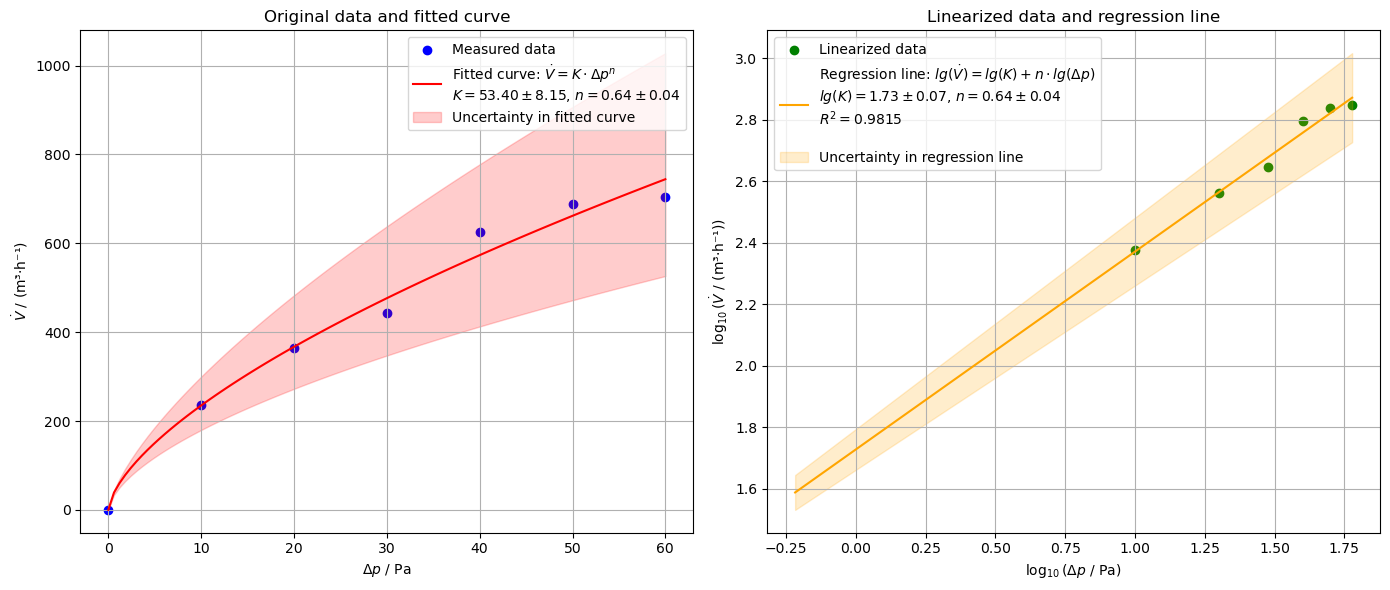

In [2]:
# Plot
# =====
# Create a range of delta_p values for plotting the fitted curve
# Range of delta_p values, including 0
delta_p_range = np.linspace(0, 60, 100)
# Corresponding log10 values, excluding 0
log_delta_p_range = np.log10(delta_p_range[1:])

# Calculate the fitted curve and regression line
# Fitted curve: V_dot = K * delta_p^n
V_dot_fitted = K * delta_p_range**n

# Regression line: log10(V_dot) = log10(K) + n * log10(delta_p)
log_V_dot_fitted = b + a * log_delta_p_range

# Uncertainty bounds in the fitted curve
V_dot_upper = (K + sigma_K) * delta_p_range**(n + sigma_n)
V_dot_lower = (K - sigma_K) * delta_p_range**(n - sigma_n)

# Uncertainty bounds n the regression line
log_V_dot_upper = (b + sigma_b) + (a + sigma_a) * log_delta_p_range
log_V_dot_lower = (b - sigma_b) + (a - sigma_a) * log_delta_p_range

# Create the plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# First pane: Original data and fitted curve with uncertainty
ax1.scatter(delta_p, V_dot,
            color='blue',
            label='Measured data')
ax1.plot(delta_p_range, V_dot_fitted,
         color='red',
         label=f'Fitted curve: $\dot{{V}} = K \cdot \Delta p^n$\n'
         f'$K = {K:.2f} \pm {sigma_K:.2f}$, $n = {n:.2f} \pm {sigma_n:.2f}$')
ax1.fill_between(delta_p_range, V_dot_lower, V_dot_upper,
                 color='red', alpha=0.2,
                 label='Uncertainty in fitted curve')
ax1.set_xlabel('$\Delta p$ / Pa')
ax1.set_ylabel('$\dot{V}$ / (m³·h⁻¹)')
ax1.set_title('Original data and fitted curve')
ax1.legend()
ax1.grid(True)

# Second pane: Linearized data and regression line with uncertainty
ax2.scatter(log_delta_p, log_V_dot,
            color='green',
            label='Linearized data')
ax2.plot(log_delta_p_range, log_V_dot_fitted, 
         color='orange',
         label=f'Regression line: '
         f'$lg(\dot{{V}}) = lg(K) + n \cdot lg(\Delta p)$\n'
         f'$lg(K) = {b:.2f} \pm {sigma_b:.2f}$, $n = {a:.2f} \pm {sigma_a:.2f}$'
         f'\n$R^2 = {r_square:.4f}$\n')
ax2.fill_between(log_delta_p_range, log_V_dot_lower, log_V_dot_upper, 
                 color='orange', alpha=0.2,
                 label='Uncertainty in regression line')
ax2.set_xlabel('$\log_{10}(\Delta p$ / Pa)')
ax2.set_ylabel('$\log_{10}(\dot{V}$ / (m³·h⁻¹))')
ax2.set_title('Linearized data and regression line')
ax2.legend()
ax2.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

**Note:** For the test results to be valid according to the standard [ISO 9972 (2015)](https://www.iso.org/standard/55718.html), $R^2$ must not be less than 0.98.

## Effective leakage area (ELA) and equivalent circular hole

[Effective Leakage Area (ELA)](https://en.wikipedia.org/wiki/Blower_door) is the total area of all building envelope leaks, idealized as a single nozzle-shaped orifice (similar to a blower door fan inlet) that passes the same airflow as the actual leaks at a reference pressure.

The effective leakage area (ELA) can be derived by combining the Bernoulli equation with the definition of volumetric flow rate and the experimental blower-door law.

### Air veocity through a leakage orifice

Consider airflow from the room (point **A**) toward a leakage opening (point **B**).

The Bernoulli equation along a streamline,

$$
p_A + \frac{1}{2}\rho v_A^2 + \rho g z_A
=
p_B + \frac{1}{2}\rho v_B^2 + \rho g z_B
$$

with the assumptions used in blower-door analysis:
- steady incompressible flow,
- negligible height difference, $z_A \approx z_B$,
- velocity in the room is very small, $v_A \approx 0$,

yields

$$
p_A = p_B + \frac{1}{2}\rho v^2
$$

By defining the pressure difference

$$
\Delta p = p_A - p_B
$$

the velocity through the opening **B** is:

$$
v = \sqrt{\frac{2\Delta p}{\rho}}
$$

### Effective Leakage Area (ELA)

The volumetric flow rate is defined as

$$
\dot{V} = A v
$$

where

- $\dot{V}$ is the volumetric airflow rate, m³/s;  
- $A$ - flow area, m²;  
- $v$ - air velocity, m/s.

Substituting the velocity obtained from Bernoulli equation:

$$
\dot{V} = A \sqrt{\frac{2\Delta p}{\rho}}
$$

we obtain the **Effective Leakage Area (ELA)**:

$$
A = \dot{V} \sqrt{\frac{\rho}{2\Delta p}}
$$

Airflow measured during blower-door tests follows an empirical relation:

$$
\dot{V} = K(\Delta p)^n
$$

where
- $K$ - flow coefficient,
- $n$ - pressure exponent,
- $\Delta p$ - pressure difference, Pa; usually 10 Pa ([ISO 9972:2015](https://www.iso.org/standard/55718.html)).

Substituting into the ELA expression:

$$
ELA = \dot{V} \sqrt{\frac{\rho}{2\Delta p}} = K(\Delta P)^n \sqrt{\frac{\rho}{2\Delta p}}
$$

The **effective leakage area (ELA)** can be interpreted as the area of an **equivalent circular hole** producing the same airflow. The diameter of the equivalent circular hole is:

$$
d = \sqrt{\frac{4\,ELA}{\pi}}
$$


In [3]:
rho = 1.2          # kg/m³, air density
delta_p = 10       # Pa, pressure difference

# airflow law (blower door) in m³/h
Vdot_m3h = K * delta_p**n

# convert to m3/s
Vdot = Vdot_m3h / 3600

# Effective leakage area in m²
ELA = Vdot / np.sqrt(2 * delta_p / rho)

# equivalent circular diameter (m)
d = np.sqrt(4 * ELA / np.pi)

print(f"Pressure difference: {delta_p:.1F} Pa")
print(f"Airflow rate: {Vdot_m3h:.1F} m³/h = {Vdot:.3F} m³/s")
print(f"Effective leakage area ELA: {ELA:.3F} m² = {10**4 * ELA:.1F} cm²")
print(f"Equivalent circular hole diameter: {d:.3F} m = {100 * d:.1F} cm")

Pressure difference: 10.0 Pa
Airflow rate: 234.9 m³/h = 0.065 m³/s
Effective leakage area ELA: 0.016 m² = 159.9 cm²
Equivalent circular hole diameter: 0.143 m = 14.3 cm


## References

[Joint Committee for Guides in Metrology. (2008)](https://www.bipm.org/documents/20126/2071204/JCGM_100_2008_E.pdf). Evaluation of measurement data—Guide to the expression of uncertainty in measurement. JCGM, 100(2008), 1-116.

[ISO 9972 (2015)](https://www.iso.org/standard/55718.html). Thermal Performance of Buildings, Determination of Air Permeability of Buildings, Fan Pressurization Method. ISO.